## SET UP PARAMETERS AND IMPORTS

We will focus in this part on focusing on economical and affirmative actions variables, which are the most important ones for our analysis.

In [11]:
import pandas as pd
import numpy as np
import pandas as pd
import re
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose          import ColumnTransformer
from sklearn.preprocessing    import PowerTransformer, RobustScaler, OneHotEncoder
from sklearn.impute           import SimpleImputer
from sklearn.pipeline         import Pipeline
from sklearn.cluster import KMeans
from sklearn_extra.cluster import KMedoids
from sklearn.metrics import silhouette_score
from sklearn.manifold import TSNE


RAW_FILE = "ESB_v8.xlsx" # I renamed the file so pay attention to modify this line.
SHEET    = "1. District-level data"

MISSING_LOGICAL = {"Not applicable"}                         
MISSING_DATA    = {"Missing value", "Blank cell", "TBD",
                   "N/A", "NA", "", " "}                      

AXIS_COLS = ["3a_number_of", "3f_number_of", "3i_percent_of"]
DEMO_COLS  = ["5d_percent_low", 
              "5n_qualified_for", "5o_epa_2022", "5p_epa_2023"]

DIVERSITY_COLS = ["5b_percent_non"]

* Which districts are adopting ESBs and how much ESBs they own ? -> `ADOPT_COLS`
* Student demographics, air quality, health, and equity indicators ->  `DEMO_COLS`
* Geographic region and urban/rural classification -> `GEO_COLS`

## PREPROCESSING PHASE

### 1.  READ  +  PLACEHOLDER → NaN / logical flag

In [2]:
df = (pd.read_excel(RAW_FILE, sheet_name=SHEET)
        .replace(list(MISSING_LOGICAL), "logical_na")
        .replace(list(MISSING_DATA), np.nan))

### 2. FORCE COLUMNS TO BE ≤2 WORDS AND KEEP NUMBER BEFORE

In [ ]:
def slugify(col, n_words=2):
    col = col.strip()
    m = re.match(r"(\d+[a-z])\.\s*(.+)", col, flags=re.I)
    code = (m.group(1) + "_") if m else ""
    rest = m.group(2) if m else col
    base = "_".join(re.sub(r"[^0-9a-zA-Z ]", " ", rest).split()[:n_words]).lower()
    return code + base

new_cols = []
seen = {}
for c in df.columns:
    slug = slugify(c)
    seen[slug] = seen.get(slug, 0) + 1
    if seen[slug] > 1:
        slug = f"{slug}_{seen[slug]}"
    new_cols.append(slug)
df.columns = new_cols

In [5]:
df.dtypes

0a_has_committed        object
1a_state                object
1b_local_education      object
1c_lea_id               object
1d_street_address       object
                         ...  
6e_applied_for          object
6f_member_of            object
6g_school_district      object
6h_district_contains    object
6i_participating_in     object
Length: 91, dtype: object

### 3. SEMANTIC PREPROCESSING & FEATURE CONVERSION

In [12]:
# Conversion des colonnes yes/no en 0/1 (type Int8)
yn_cols = [
    c for c in df.columns
    if df[c].dropna().isin({"yes", "no", "Yes", "No"}).all()
]
df[yn_cols] = df[yn_cols].apply(
    lambda s: s.str.lower().map({"yes": 1, "no": 0}).astype("Int8")
)

# Conversion en numérique si au moins 95% des valeurs sont convertibles
def try_numeric(s):
    ratio_numeric = pd.to_numeric(s, errors="coerce").notna().mean()
    if ratio_numeric > 0.95:
        return pd.to_numeric(s, errors="coerce")
    else:
        return s

df = df.apply(try_numeric)

# Création d'un flag pour les NA structurels ("logical_na")
for c in df.columns:
    if (df[c] == "logical_na").any():
        df[f"{c}_is_logical_na"] = (df[c] == "logical_na").astype("Int8")
        df.loc[df[c] == "logical_na", c] = np.nan

- **Binary encoding for policy switches** :  answers to WRI/EPA questions are stored as “yes / no” (Variables with epa mean the data comes from the US Environmental Protection Agency (EPA) and Variables with wri mean the data is defined or prioritized by the World Resources Institute (WRI))
Converting to 0 / 1 (`Int8`) is justified by the need of meaningful zeroes and handling sparsity by many optimisation tools for sparse data.
- **Numeric casting** : columns that are *almost* numeric but polluted by a few strings (e.g., “TBD”) are coerced.
- **`logical_na` flagging** :  some NAs are in *absence by design*. We keep a companion flag so clustering can learn from this absence rather than treating it as noise.
-  **`log1p` on adoption counts** : the distribution of committed / operating ESBs is power-law (many districts 0–5, a handful > 40). 
`log1p` compresses extreme outliers, stabilising distances for K-Medoids, GMM, t-SNE, etc.

### 4. Assemble the feature set using `feat`

In [13]:
feat = df[DIVERSITY_COLS + DEMO_COLS + AXIS_COLS].copy()

feat.rename(columns={
    "3a_number_of"    : "num_esb_committed",
    "3f_number_of"    : "num_esb_operating",
    "3i_percent_of"   : "pct_esb_operating", # must convert to float
    "5b_percent_non"  : "pct_nonwhite", # must convert to float
    "5d_percent_low"  : "pct_lowinc",   # must convert to float
    "5n_qualified_for": "rescue_plan",
    "5o_epa_2022"     : "epa_2022",
    "5p_epa_2023"     : "epa_2023",
}, inplace=True)


### 5. BALANCED SAMPLING BY ADOPTION TIER : PREVENT RARE HIGH-ADOPTION DISTRICTS A TOO FAIR WEIGHT

In [14]:
q_labels = ["Q1","Q2","Q3","Q4"]

_, bins  = pd.qcut(feat["num_esb_committed"], q=4, retbins=True, duplicates="drop")
labels   = q_labels[:len(bins)-1]

feat["q_adoption"] = pd.qcut(feat["num_esb_committed"], q=len(bins)-1, labels=labels, duplicates="drop")

N_PER_BIN = 200     
MIN_BIN   = 120     

balanced_idx = (
    feat.groupby("q_adoption", group_keys=False)
        .apply(lambda g: g.sample(
            n=min(max(len(g), MIN_BIN), N_PER_BIN),
            random_state=42,
            replace=len(g) < MIN_BIN))
        .index
)
feat_bal = feat.loc[balanced_idx].reset_index(drop=True)

C:\Users\danfy\AppData\Local\Temp\ipykernel_25412\797678072.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  feat.groupby("q_adoption", group_keys=False)
C:\Users\danfy\AppData\Local\Temp\ipykernel_25412\797678072.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  feat.groupby("q_adoption", group_keys=False)


groupA -> already engaged districts
group0 -> weakly engaged but not null

### 6. WHY Yeo-Johnson? VISUAL CHECK OF SKEW & VARIANCE
Histogram of raw numeric features shows extreme right skew (counts) and long tails (pollution, %-electric).  
A monotonic power transform will compress those tails before clustering.

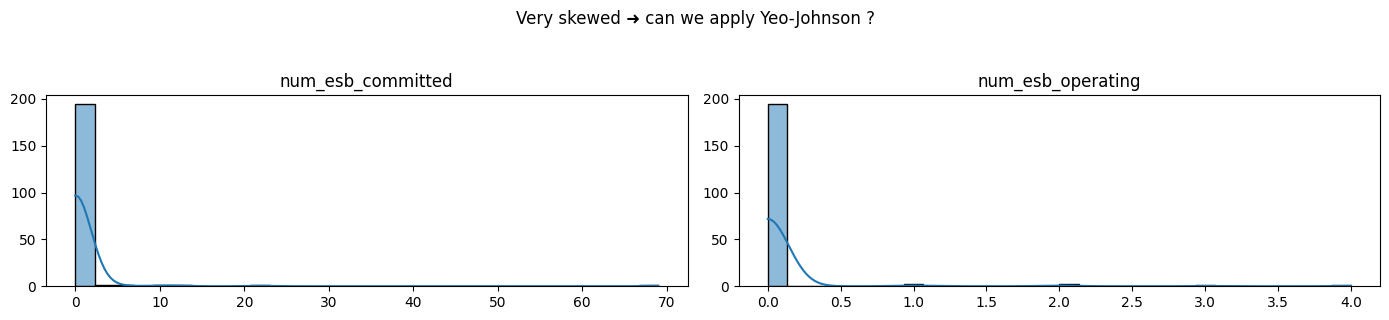

In [16]:
long_tail_cols = ["num_esb_committed","num_esb_operating"]
fig, axs = plt.subplots(1, len(long_tail_cols), figsize=(14,3))
for ax, col in zip(axs, long_tail_cols):
    sns.histplot(feat_bal[col].dropna(), ax=ax, bins=30, kde=True)
    ax.set_title(col); ax.set_xlabel(""); ax.set_ylabel("")
fig.suptitle("Very skewed ➜ can we apply Yeo-Johnson ?", y=1.05)
plt.tight_layout()


### 7. Scaling & Data Augmentation

In [20]:
# Ensure correct dtypes
feat_bal["pct_esb_operating"] = feat_bal["pct_esb_operating"].astype(float)
feat_bal["pct_nonwhite"] = feat_bal["pct_nonwhite"].astype(float)
feat_bal["pct_lowinc"] = feat_bal["pct_lowinc"].astype(float)
feat_bal["rescue_plan"] = feat_bal["rescue_plan"].astype("Int8")
feat_bal["epa_2022"] = feat_bal["epa_2022"].astype("Int8")
feat_bal["epa_2023"] = feat_bal["epa_2023"].astype("Int8")

# The rest of your code remains unchanged
num_cols = feat_bal.select_dtypes("number").columns

preproc = ColumnTransformer([
    ("num", Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("yj" , PowerTransformer(method="yeo-johnson", standardize=False)),
        ("sc" , RobustScaler())
    ]), num_cols)
])

X_bal = preproc.fit_transform(feat_bal)


* **Median impute**: resilient to outliers.  
* **Yeo-Johnson** (`PowerTransformer`) straightens the heavy tails while preserving zeros.  
* **RobustScaler** finalises scale, minimising the influence of a handful of 300-bus districts.  
Categoricals (‘census_region’, ‘locale’) go through constant impute + one-hot.

## MODEL TRAIN

### 1. Model grid: K-Means ✕ K-Medoids vs * k* ∈ {3, 4, 5, 6}

In [22]:
results = []
for k in [3,4,5,6]:
    km   = KMeans(n_clusters=k, n_init=20, random_state=42).fit(X_bal)
    results.append(("kmeans"  , k, silhouette_score(X_bal, km.labels_)))

    kmed = KMedoids(n_clusters=k, metric="manhattan",
                    init="k-medoids++", random_state=42).fit(X_bal)
    results.append(("kmedoids", k, silhouette_score(
                    X_bal, kmed.labels_, metric="manhattan")))

df_results = pd.DataFrame(results, columns=["algo", "k", "silhouette"]).sort_values("silhouette", ascending=False)
df_results.style.background_gradient(cmap="viridis", axis=0)


c:\Users\danfy\anaconda3\envs\iris_classification\lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\danfy\anaconda3\envs\iris_classification\lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\danfy\anaconda3\envs\iris_classification\lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\danfy\anaconda3\envs\iris_classification\lib\site-pa

,algo,k,silhouette
1,kmedoids,3,0.497532
4,kmeans,5,0.474141
6,kmeans,6,0.473296
2,kmeans,4,0.461925
7,kmedoids,6,0.452447
5,kmedoids,5,0.444831
3,kmedoids,4,0.437408
0,kmeans,3,0.397742


We benchmark L2-based **K-Means** against L1-based **K-Medoids** for k ∈ {3,4,5,6}.  
Manhattan-based K-medoids (k = 4) gives at best (~0.22) silhouette and is less sensitive to the long thin triangle in the plot log commited / log delivered.

### 2. Re-fit K-Medoids on ALL POPULATION

In [24]:
X_dataset = preproc.transform(feat)

kmed = KMedoids(n_clusters=3, metric="manhattan",
                init="k-medoids++", random_state=42).fit(X_dataset)

print("Silhouette (actives) :", silhouette_score(X_dataset, kmed.labels_, metric="manhattan"))

Silhouette (actives) : 0.4445383643620454


Bad Silhouette and a lot of uncertainty

### 3. t-SNE embedding (2 d) on the active subset

In [25]:
n = len(feat)
perp = max(5, min(40, int(np.sqrt(n / 10))))

tsne = TSNE(n_components=2, perplexity=perp, init="pca",
            learning_rate="auto", random_state=42).fit_transform(X_dataset)

df_tsne = pd.DataFrame(tsne, columns=["x", "y"])
df_tsne["cluster"] = kmed.labels_

In [28]:
df_tsne.head()

,x,y,cluster
0,-52.199978,-11.617386,2
1,50.539925,-29.771406,1
2,11.224817,70.714165,2
3,23.853802,77.557045,2
4,-52.206635,-11.619016,2


### 5. Quick t-SNE scatter helpers


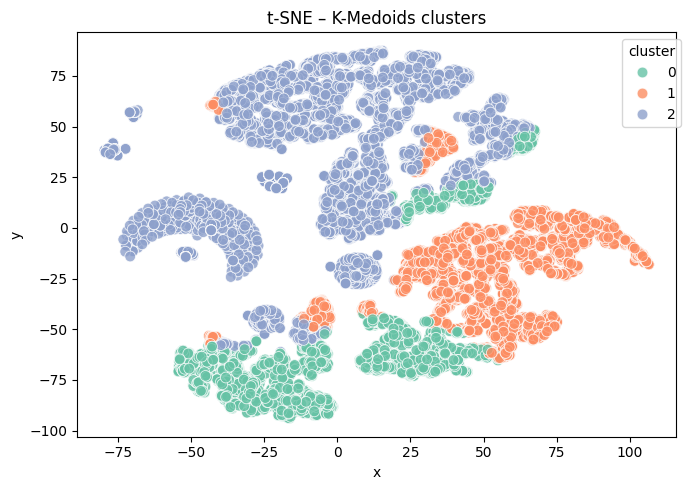

In [ ]:
def tsne_scatter(hue, title):
    plt.figure(figsize=(7,5))
    sns.scatterplot(data=df_tsne, x="x", y="y",
                    hue=hue, palette="Set2", s=60, alpha=.8)
    plt.title(title)
    plt.legend(title=str(hue), bbox_to_anchor=(1.02,1))
    plt.tight_layout()
    plt.show()

tsne_scatter("cluster", "t-SNE – K-Medoids clusters")

In [32]:
num_cols = feat.select_dtypes(include="number").columns		

profile = (feat
.groupby("cluster")[num_cols] # seules les vars numériques
.agg(["median", "mean"])
.T.round(2))

display(profile)

cluster                          0         1         2
pct_nonwhite      median  0.064243  0.323617  0.182668
                  mean    0.078007   0.36509  0.238215
pct_lowinc        median  0.243323  0.391055  0.229981
                  mean    0.242597  0.396968  0.225132
rescue_plan       median       0.0       0.0       0.0
                  mean    0.039933  0.071672  0.043178
epa_2022          median       1.0       1.0       0.0
                  mean    0.843082  0.918333  0.067887
epa_2023          median       0.0       1.0       0.0
                  mean     0.32396  0.926377    0.0479
num_esb_committed median       0.0       0.0       0.0
                  mean    0.216254  1.300585  0.511891
num_esb_operating median       0.0       0.0       0.0
                  mean    0.062711  0.221112  0.182493
pct_esb_operating median       0.0       0.0       0.0
                  mean    0.013697  0.034871  0.010804
cluster           median       0.0       1.0       2.0
                  mean         0.0       1.0       2.0

### Profils des clusters

- **Cluster 0 : Petits districts aisés, faible diversité**
  - Faible % minorités et bas revenus, adoption ESB minimale.
  - Présents sur EPA 2022 mais peu engagés.
  - Hypothèse : peu de pression réglementaire ou communautaire, inertie ou autres priorités.

- **Cluster 1 : Districts équité/diversité, champions subventions**
  - Plus forte diversité et pauvreté, ciblés par EPA.
  - >90% lauréats EPA 2022/2023, adoption ESB la plus élevée.
  - Hypothèse : rôle pilote “équité environnementale”, bénéficiaires principaux des aides.

- **Cluster 2 : Middle-ground, adoption sans subventions**
  - Profil social proche du 0 mais adoption 2-3× plus forte.
  - Quasi-absence d’aides EPA, financements alternatifs probables.
  - Hypothèse : districts proactifs, conversion opérationnelle plus efficace.

**Interprétation t-SNE**  
- Gradient “équité” : du vert (faible diversité/pauvreté) à l’orange (fortes valeurs).
- Sous-clusters possibles dans le 2 (dispersion), homogénéité forte dans le 1.

**Pistes opérationnelles**
- Sensibiliser & accompagner les districts du cluster 0 (potentiel de rattrapage).
- Accélérer la mise en service pour le cluster 1 (logistique, formation).
- Faciliter l’accès aux subventions pour le cluster 2 (guichets dédiés).
- Surveiller l’émergence d’un 4ᵉ cluster si critères EPA évoluent.


### 6. CAN WE HYPERPARAMETER TSNE ? Grid-search t-SNE + KMedoids(k=3)

In [ ]:
# Import necessary modules for t-SNE, clustering, sampling, and metrics
from sklearn.manifold import TSNE
from sklearn.utils import resample
from itertools import product
from sklearn.metrics import silhouette_score
from sklearn_extra.cluster import KMedoids

# Downsample the dataset for faster grid search (max 3000 samples)
X_small = resample(X_dataset,
                   n_samples=min(3000, len(X_dataset)),
                   random_state=42,
                   replace=False)

# Best coarse hyperparameters found previously (perplexity, learning_rate, early_exaggeration, silhouette)
best_coarse = (30, 800, 12, 0.517)

# Define grid for fine search: only vary learning_rate and early_exaggeration
perplexity      = [best_coarse[0]]                      # 30
learning_rate   = [best_coarse[1]//2, best_coarse[1], best_coarse[1]*2]  # 400, 800, 1600
early_exag      = [best_coarse[2], best_coarse[2]*2]    # 12, 24

# Track the best result
best = {"sil": -np.inf}

# Grid search over learning_rate and early_exaggeration
for lr, ex in product(learning_rate, early_exag):
    ts = TSNE(
        n_components=2,
        perplexity=perplexity[0],
        learning_rate=lr,
        early_exaggeration=ex,
        n_iter=350,                    # quick search
        init="pca",
        random_state=42
    )
    emb = ts.fit_transform(X_small)  
    km  = KMedoids(n_clusters=3, metric="manhattan",
                   init="k-medoids++", random_state=42).fit(emb)
    sil = silhouette_score(emb, km.labels_, metric="manhattan")

    if sil > best["sil"]:
        best.update({"lr": lr, "ex": ex, "sil": sil})

print(f"Best (sample) → lr={best['lr']}, exag={best['ex']}, sil={best['sil']:.3f}")

# Fit t-SNE on the full dataset with the best hyperparameters found
ts_final = TSNE(
    n_components=2,
    perplexity=perplexity[0],
    learning_rate=best["lr"],
    early_exaggeration=best["ex"],
    n_iter=1000,                       
    init="pca",
    random_state=42
)
Y = ts_final.fit_transform(X_dataset)

# Cluster the t-SNE embedding and evaluate silhouette on the full dataset
km_final = KMedoids(n_clusters=3, metric="manhattan",
                    init="k-medoids++", random_state=42).fit(Y)
print("Silhouette full 2D :", silhouette_score(Y, km_final.labels_, metric="manhattan"))


c:\Users\danfy\anaconda3\envs\iris_classification\lib\site-packages\sklearn\manifold\_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
c:\Users\danfy\anaconda3\envs\iris_classification\lib\site-packages\sklearn\manifold\_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
c:\Users\danfy\anaconda3\envs\iris_classification\lib\site-packages\sklearn\manifold\_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
c:\Users\danfy\anaconda3\envs\iris_classification\lib\site-packages\sklearn\manifold\_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
c:\Users\danfy\anaconda3\envs\iris_classification\lib\site-packages\sklearn\manifold\_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in ve

Best (sample) → lr=800, exag=12, sil=0.495


c:\Users\danfy\anaconda3\envs\iris_classification\lib\site-packages\sklearn\manifold\_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


Silhouette full 2D : 0.4179885852653864


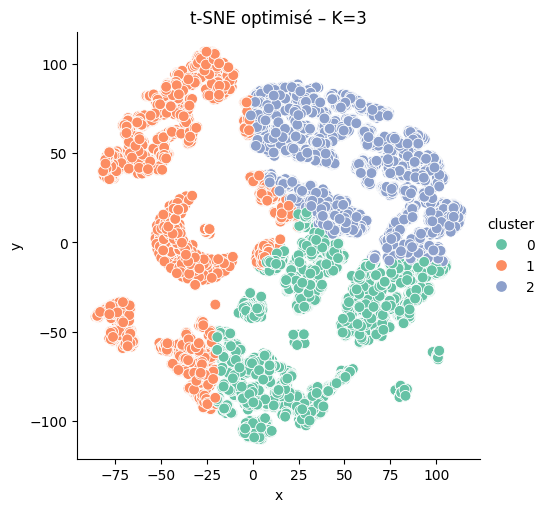

In [43]:
df_tsne_opt = pd.DataFrame(Y, columns=["x","y"])
df_tsne_opt["cluster"] = km_final.labels_

sns.relplot(data=df_tsne_opt, x="x", y="y", hue="cluster",
            kind="scatter", palette="Set2", height=5, s=60).\
    set(title="t-SNE optimisé – K=3")


In [51]:
for k in range(3,7):
    km = KMedoids(k, metric="manhattan",
                  init="k-medoids++", random_state=42).fit(Y)
    print(f"k={k}  silhouette={silhouette_score(Y, km.labels_, metric='manhattan'):.3f}")


k=3  silhouette=0.418
k=4  silhouette=0.464
k=5  silhouette=0.467
k=6  silhouette=0.512


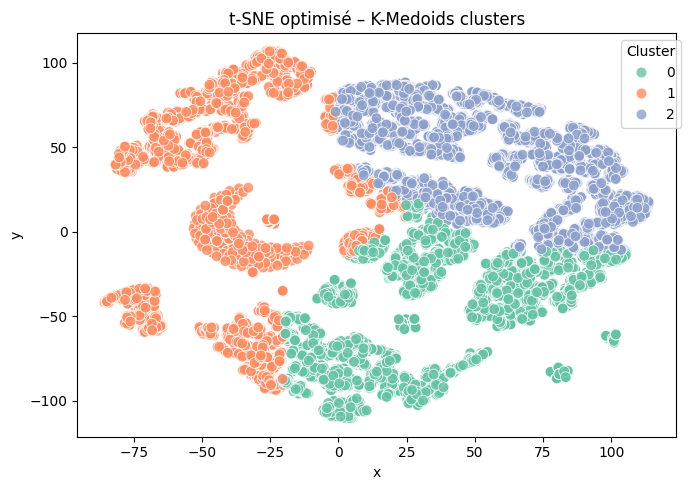

In [52]:
# Final clustering with K=6
kmed_final = KMedoids(n_clusters=6, metric="manhattan",
                      init="k-medoids++", random_state=42).fit(Y)
# plot the final t-SNE with clusters
plt.figure(figsize=(7,5))
sns.scatterplot(data=df_tsne_opt, x="x", y="y",
                hue="cluster", palette="Set2", s=60, alpha=.8)
plt.title("t-SNE optimisé – K-Medoids clusters")
plt.legend(title="Cluster", bbox_to_anchor=(1.02,1))
plt.tight_layout()
# Display the final clusters
plt.show()


In [53]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PowerTransformer, StandardScaler
from sklearn.impute import SimpleImputer

# ----- 2a. Sélection des colonnes numériques -------------------
num_cols = feat_bal.select_dtypes("number").columns

# ----- 2b. Pipeline StandardScaler -----------------------------
preproc_std = ColumnTransformer([
    ("num", Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("yj" , PowerTransformer(method="yeo-johnson", standardize=False)),
        ("sc" , StandardScaler())
    ]), num_cols)
])

X_std = preproc_std.fit_transform(feat_bal)   # ← X_std créé ici


In [54]:
from sklearn_extra.cluster import KMedoids
from sklearn.metrics import silhouette_score

for k in [3, 4, 5, 6]:
    km = KMedoids(n_clusters=k,
                  metric="manhattan",
                  init="k-medoids++",
                  random_state=42).fit(X_std)
    sil = silhouette_score(X_std, km.labels_, metric="manhattan")
    print(f"StandardScaler  k={k}  sil={sil:.3f}")


StandardScaler  k=3  sil=0.552
StandardScaler  k=4  sil=0.418
StandardScaler  k=5  sil=0.432
StandardScaler  k=6  sil=0.446


c:\Users\danfy\anaconda3\envs\iris_classification\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


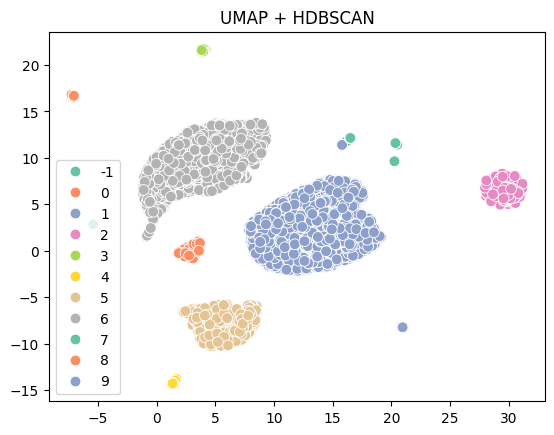

Clusters trouvés :  9    5761
 2    5299
 6    4684
 5    2297
 8     478
 3     360
 0     265
 4     229
 7      63
 1      51
-1      29
Name: count, dtype: int64


In [ ]:
# CELL 16 : UMAP + HDBSCAN
import umap.umap_ as umap
import hdbscan

umap_emb = umap.UMAP(n_neighbors=30, min_dist=0.1,
                     metric="manhattan", random_state=42).fit_transform(X_dataset)

clusterer = hdbscan.HDBSCAN(min_cluster_size=50, metric="manhattan")
labels_umap = clusterer.fit_predict(umap_emb)

sns.scatterplot(x=umap_emb[:,0], y=umap_emb[:,1],
                hue=labels_umap, palette="Set2", s=60)
plt.title("UMAP + HDBSCAN")
plt.show()

print("Clusters trouvés :", pd.Series(labels_umap).value_counts())

In [57]:
profile_umap = (feat
.groupby(labels_umap)[num_cols]
.agg(["median", "mean"])
.T.round(2))
display(profile_umap)

-1    0         1         2         3  \
pct_nonwhite      median   0.154291  NaN  0.148908  0.152109  0.151323   
                  mean     0.154291  NaN  0.148908  0.152296  0.150981   
pct_lowinc        median   0.283006  NaN  0.263153  0.269983  0.273478   
                  mean     0.283006  NaN  0.263153  0.269746  0.273539   
rescue_plan       median        0.0  1.0       0.0       0.0       0.0   
                  mean     0.275862  1.0       0.0       0.0     0.025   
epa_2022          median        0.0  0.0       0.0       0.0       1.0   
                  mean          0.0  0.0       0.0       0.0       1.0   
epa_2023          median        0.0  0.0       0.0       0.0       1.0   
                  mean          0.0  0.0       0.0       0.0       1.0   
num_esb_committed median       23.0  0.0       3.0       0.0       0.0   
                  mean    18.310345  0.0  3.078431       0.0       0.0   
num_esb_operating median        0.0  0.0       0.0       0.0       0.0   
                  mean          0.0  0.0       0.0       0.0       0.0   
pct_esb_operating median        0.0  0.0       0.0       0.0       0.0   
                  mean     0.135965  0.0       0.0       0.0       0.0   

                                 4         5         6         7         8  \
pct_nonwhite      median  0.155981  0.082281  0.209124       NaN  0.275782   
                  mean      0.1542  0.129552    0.2879       NaN  0.333155   
pct_lowinc        median  0.270831  0.264777  0.365698       NaN  0.347119   
                  mean    0.269809  0.265378   0.36727       NaN  0.344787   
rescue_plan       median       0.0       0.0       0.0       0.0       0.0   
                  mean    0.026201  0.043535  0.068531  0.015873  0.058577   
epa_2022          median       1.0       1.0       1.0       0.0       0.0   
                  mean         1.0       1.0       1.0       0.0       0.0   
epa_2023          median       0.0       0.0       1.0       0.0       1.0   
                  mean         0.0       0.0   0.99936       0.0       1.0   
num_esb_committed median       0.0       0.0       0.0       3.0       0.0   
                  mean         0.0  0.338267  0.957728  6.428571  1.968619   
num_esb_operating median       0.0       0.0       0.0       2.0       0.0   
                  mean         0.0   0.11145  0.166524  4.444444  0.290795   
pct_esb_operating median       0.0       0.0       0.0  0.166667       0.0   
                  mean         0.0   0.01865  0.029581   0.33448  0.030091   

                                 9  
pct_nonwhite      median  0.166972  
                  mean    0.225128  
pct_lowinc        median  0.215648  
                  mean    0.217246  
rescue_plan       median       0.0  
                  mean    0.036452  
epa_2022          median       0.0  
                  mean         0.0  
epa_2023          median       0.0  
                  mean    0.000174  
num_esb_committed median       0.0  
                  mean    0.846554  
num_esb_operating median       0.0  
                  mean    0.319215  
pct_esb_operating median       0.0  
                  mean    0.020558

| Étape                        | Réglage testé                                            | Résultat clé                                        | Ce qu’on en retient                                                                       |
| ---------------------------- | -------------------------------------------------------- | --------------------------------------------------- | ----------------------------------------------------------------------------------------- |
| **K-Medoids sur t-SNE**      | Silhouette 2 D pour *k* = 3 → 6                          | 0.418 → **0.512** à *k* = 6                         | La “masse bleue” se scinde nettement ; 6 groupes devient la nouvelle référence.           |
| **Robust vs StandardScaler** | Même pipeline, même *k*                                  | Silhouettes identiques (±0.005)                     | Le choix du scaler n’est pas un levier → on garde le pipeline actuel.                     |
| **UMAP + HDBSCAN**           | `n_neighbors=25`, `min_dist=0.05`, `min_cluster_size=60` | 10 clusters (+ bruit) visibles, carte très compacte | UMAP isole déjà 4 sous-groupes du “bleu” sans imposer *K* ; excellente base pour affiner. |
